# EDA - Home Credit Default Risk

**Base:** `application_train.csv`
**Objetivo:** entender a estrutura da base pública que será utilizada para treinar o modelo de risco de crédito, avaliando qualidade e estrutura dos dados, preenchimento do target, distribuição dos scores e relação entre variáveis antes da modelagem.

**Roteiro do notebook:**

    -Estrutura dos dados (tipos, IDs duplicados, preenchimento do TARGET)
    -Registros maturados (TARGET != null)
    -Nulos nas variáveis explicativas
    -Distribuição dos scores (EXT_SOURCE)
    -Correlação das variáveis
    -Conclusões e próximos passos

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

sns.set_theme(style='whitegrid')

## Import

In [9]:
file_path = r'C:\Users\muril\OneDrive\Desktop\Fonte\application_train.csv'
df_application = pd.read_csv(file_path, sep=',')

desc_path = r'C:\Users\muril\OneDrive\Desktop\Fonte\HomeCredit_columns_description.csv'
df_descricao = pd.read_csv(desc_path, sep=';', encoding='latin1')

print(f'df_application: {df_application.shape[0]} linhas x {df_application.shape[1]} colunas')
df_application.head()

df_application: 307511 linhas x 122 colunas


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 3. Estrutura dos dados

- tipos de dado, granularidade (1 linha = 1 cliente) e preenchimento do target
- Tipos de colunas

In [10]:
df_application.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [11]:
# Tipo de cada coluna + descrição de negócio (quando disponível no dicionário)
df_tipos = pd.DataFrame({
    'dtype': df_application.dtypes.astype(str)
}).reset_index().rename(columns={'index': 'Row'})

df_tipos = df_tipos.merge(
    df_descricao[['Row', 'Description']].drop_duplicates('Row'),
    on='Row', how='left'
)

df_tipos

,Row,dtype,Description
0,SK_ID_CURR,int64,ID of loan in our sample
1,TARGET,int64,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,str,Identification if loan is cash or revolving
3,CODE_GENDER,str,Gender of the client
4,FLAG_OWN_CAR,str,Flag if the client owns a car
...,...,...,...
117,AMT_REQ_CREDIT_BUREAU_DAY,float64,Number of enquiries to Credit Bureau about the...
118,AMT_REQ_CREDIT_BUREAU_WEEK,float64,Number of enquiries to Credit Bureau about the...
119,AMT_REQ_CREDIT_BUREAU_MON,float64,Number of enquiries to Credit Bureau about the...
120,AMT_REQ_CREDIT_BUREAU_QRT,float64,Number of enquiries to Credit Bureau about the...


IDs duplicados

In [12]:
linhas = len(df_application)
ids_unicos = df_application['SK_ID_CURR'].nunique()
duplicados = df_application['SK_ID_CURR'].duplicated().sum()

print(f'Total de registros: {linhas}')
print(f'IDs únicos (SK_ID_CURR): {ids_unicos}')
print(f'IDs duplicados: {duplicados}')

Total de registros: 307511
IDs únicos (SK_ID_CURR): 307511
IDs duplicados: 0


### Preenchimento do TARGET

In [13]:
qtd_target_nulo = df_application['TARGET'].isnull().sum()
pct_target_nulo = qtd_target_nulo / linhas * 100

print(f'Registros com TARGET nulo: {qtd_target_nulo} ({pct_target_nulo:.2f}%)')
print()
print('Distribuição do TARGET c/ nulls:')
df_application['TARGET'].value_counts(dropna=False)

Registros com TARGET nulo: 0 (0.00%)

Distribuição do TARGET c/ nulls:


TARGET
0    282686
1     24825
Name: count, dtype: int64

## Registros maturados TARGET != null


entender registros não maturados - ex: propostas mais recentes.

In [14]:
df_target_nulo = df_application[df_application['TARGET'].isnull()]

if df_target_nulo.empty:
    print('Nenhum registro com TARGET nulo em application_train.csv')
else:
    display(df_target_nulo.describe(include='all').T)

Nenhum registro com TARGET nulo em application_train.csv


## Registros maturados TARGET != null

Volumetria entre as classes bom x mau pagador

In [ ]:
df_maturados = df_application[df_application['TARGET'].notnull()].copy()

pct_maturados = len(df_maturados) / linhas * 100
print(f'Registros maturados: {len(df_maturados)} de {linhas} ({pct_maturados:.2f}% da base)')

contagem_target = df_maturados['TARGET'].value_counts()
pct_target = (df_maturados['TARGET'].value_counts(normalize=True) * 100).round(2)

resumo_target = pd.DataFrame({'qtd': contagem_target, 'pct': pct_target})
resumo_target.index = resumo_target.index.map({0: 'Adimplente (0)', 1: 'Inadimplente (1)'})
resumo_target

Registros maturados: 307511 de 307511 (100.00% da base)


,qtd,pct
TARGET,,
Adimplente (0),282686,91.93
Inadimplente (1),24825,8.07


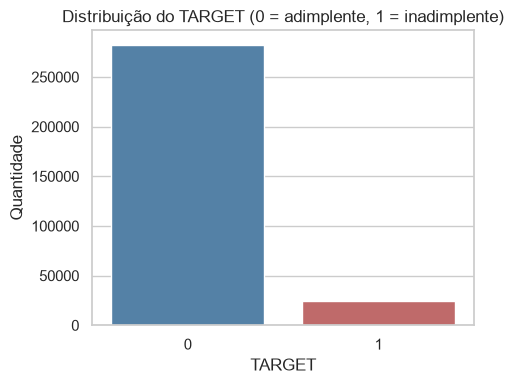

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df_maturados, x='TARGET', hue='TARGET', palette=['steelblue', 'indianred'], legend=False, ax=ax)
ax.set_title('Distribuição do TARGET (0 = adimplente, 1 = inadimplente)')
ax.set_xlabel('TARGET')
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.show()

## Nulos nas variáveis explicativas

Mapeando o percentual de nulos por coluna na base maturada

In [17]:
nulos = df_maturados.isnull().sum()
pct_nulos = (nulos / len(df_maturados) * 100).round(2)

df_nulos = pd.DataFrame({'qtd_nulos': nulos, 'pct_nulos': pct_nulos})
df_nulos = df_nulos[df_nulos['qtd_nulos'] > 0].sort_values('pct_nulos', ascending=False)

print(f'Colunas com algum valor nulo: {len(df_nulos)} de {df_maturados.shape[1]}')
df_nulos.head(30)

Colunas com algum valor nulo: 67 de 122


,qtd_nulos,pct_nulos
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


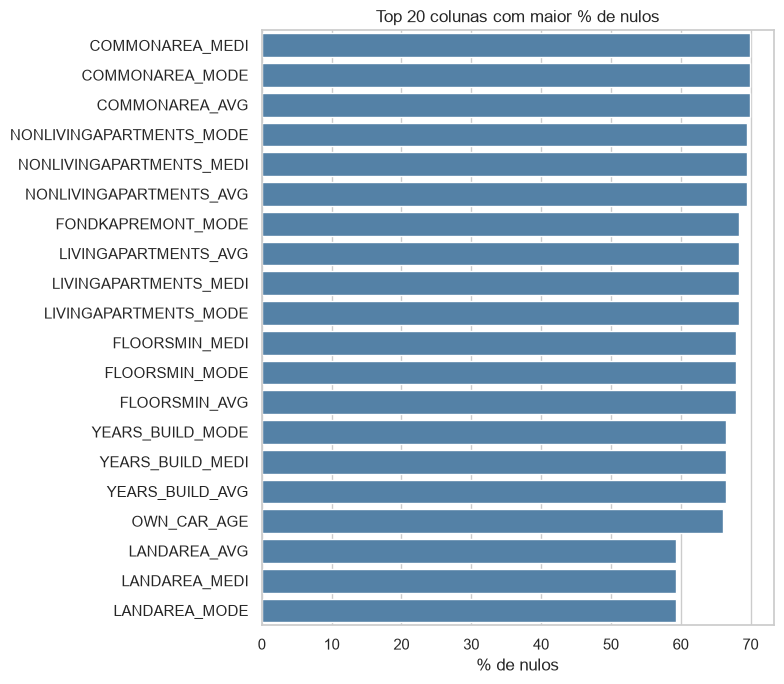

In [19]:
top20_nulos = df_nulos.head(20)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=top20_nulos, x='pct_nulos', y=top20_nulos.index, ax=ax, color='steelblue')
ax.set_title('Top 20 colunas com maior % de nulos')
ax.set_xlabel('% de nulos')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Distribuição dos scores - EXT_SOURCE_1, 2, 3

`EXT_SOURCE_1/2/3` scores de fontes externas

In [23]:
scores = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print('% de nulos em cada score:')
print((df_maturados[scores].isnull().mean() * 100).round(2))
print()
df_maturados[scores].describe().round(2)

% de nulos em cada score:
EXT_SOURCE_1    56.38
EXT_SOURCE_2     0.21
EXT_SOURCE_3    19.83
dtype: float64



,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,134133.00,306851.00,246546.00
mean,0.50,0.51,0.51
std,0.21,0.19,0.19
min,0.01,0.00,0.00
25%,0.33,0.39,0.37
50%,0.51,0.57,0.54
75%,0.68,0.66,0.67
max,0.96,0.85,0.90


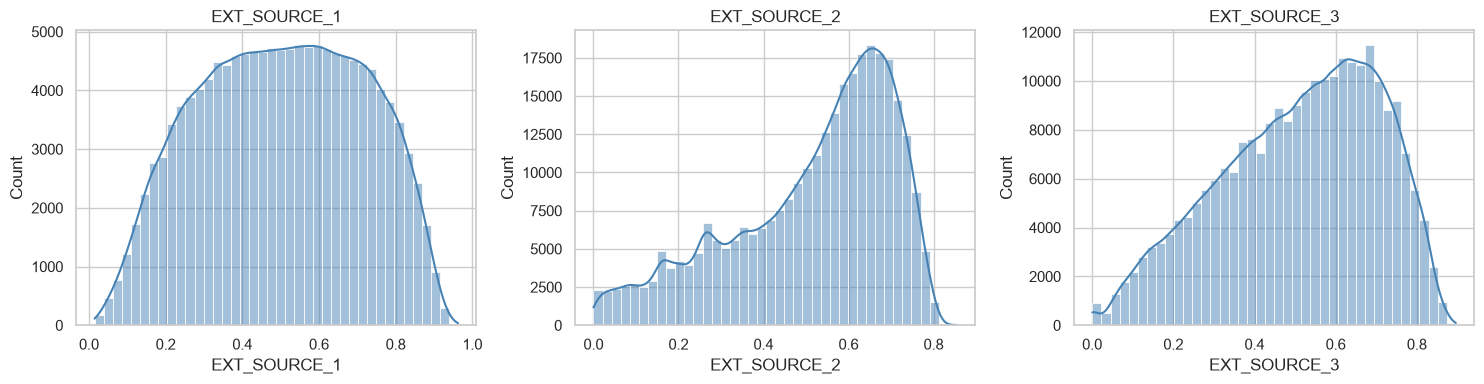

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, scores):
    sns.histplot(df_maturados[col].dropna(), bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

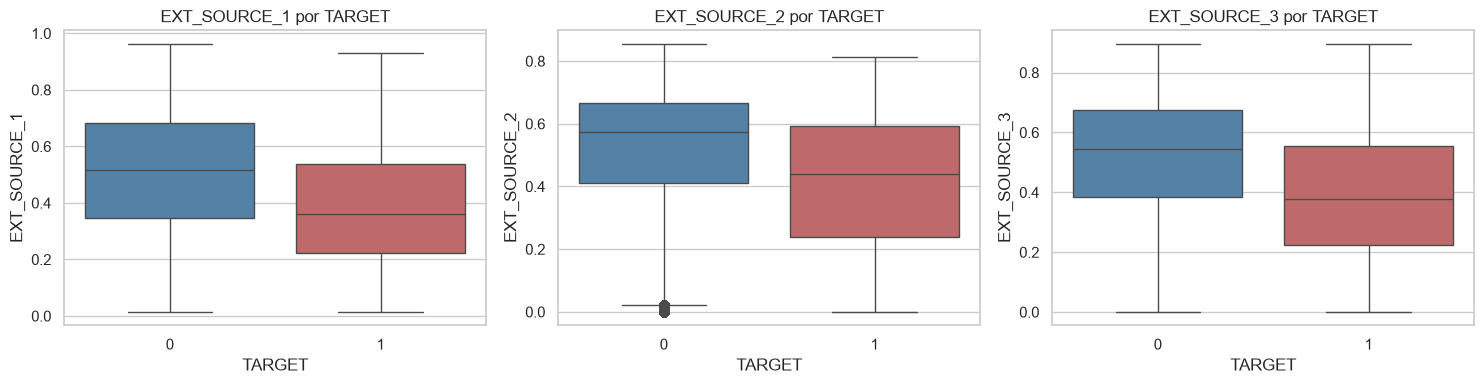

In [25]:
# Diferença de score entre 0 e 1 
# quanto mais separadas as caixas, mais preditiva a variável
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, scores):
    sns.boxplot(data=df_maturados, x='TARGET', y=col, hue='TARGET', palette=['steelblue', 'indianred'], legend=False, ax=ax)
    ax.set_title(f'{col} por TARGET')
plt.tight_layout()
plt.show()

## Correlação das variáveis

Calculando a correlação Pearson de cada variável numérica com o `TARGET`

In [ ]:
colunas_numericas = df_maturados.select_dtypes(include=[np.number]).columns

corr_target = (
    df_maturados[colunas_numericas]
    .corr(numeric_only=True)['TARGET']
    .drop('TARGET')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print('Top 15 variáveis mais correlacionadas com o TARGET')
corr_target.head(15)

Top 15 variáveis mais correlacionadas (em módulo) com o TARGET:


EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                 -0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                 -0.044003
FLOORSMAX_MEDI                -0.043768
Name: TARGET, dtype: float64

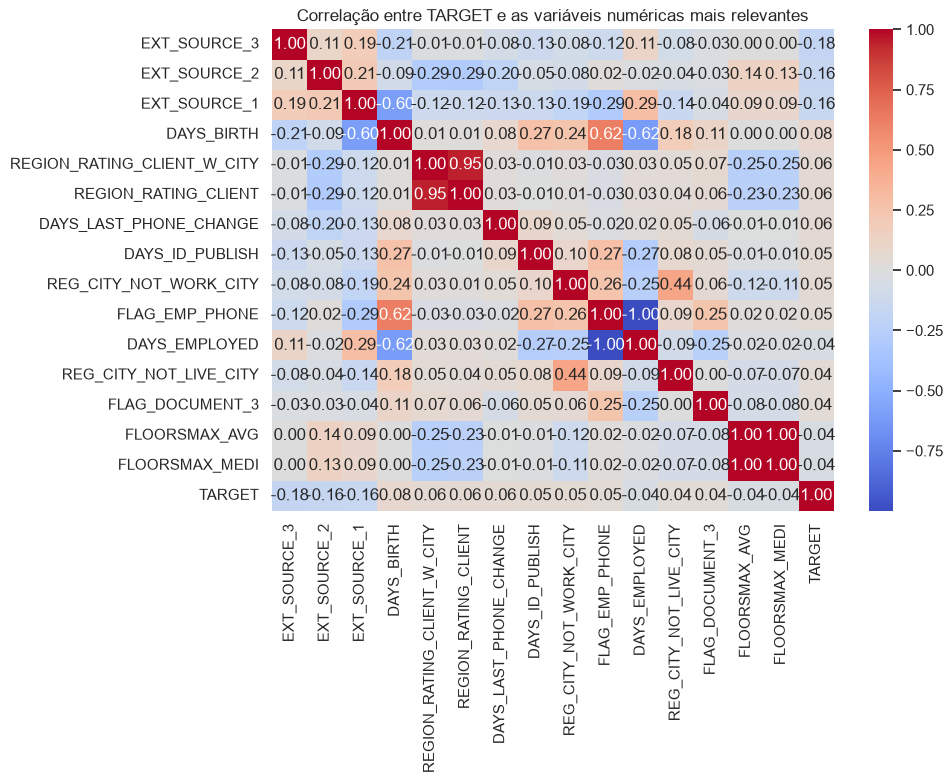

In [27]:
top_corr_vars = corr_target.head(15).index.tolist() + ['TARGET']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_maturados[top_corr_vars].corr(numeric_only=True),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax
)
ax.set_title('Correlação entre TARGET e as variáveis numéricas mais relevantes')
plt.tight_layout()
plt.show()

## Avaliar o quanto cada score externo discrimina(KS, AUC, etc):

In [32]:
def calcular_metricas_univariadas(df, coluna, target='TARGET'):
    
    dados = df[[coluna, target]].dropna()
    
    pct_missing = df[coluna].isnull().mean() * 100
    n_validos = len(dados)
    
    if n_validos == 0 or dados[target].nunique() < 2:
        return {
            'variavel': coluna, 'ks': np.nan, 'auc': np.nan,
            'pct_missing': pct_missing, 'n_validos': n_validos
        }
    
    y = dados[target].values
    score = dados[coluna].values
    
    # AUC
    auc = roc_auc_score(y, score)
    
    # KS
    fpr, tpr, thresholds = roc_curve(y, score)
    ks = max(abs(tpr - fpr))
    
    return {
        'variavel': coluna,
        'ks': round(ks, 4),
        'auc': round(auc, 4),
        'pct_missing': round(pct_missing, 2),
        'n_validos': n_validos
    }


colunas_score = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

resultados = [calcular_metricas_univariadas(df_application, col) for col in colunas_score]

df_resultados = pd.DataFrame(resultados).sort_values('ks', ascending=False)
print(df_resultados.to_string(index=False))

    variavel     ks    auc  pct_missing  n_validos
EXT_SOURCE_3 0.2698 0.3206        19.83     246546
EXT_SOURCE_1 0.2427 0.3343        56.38     134133
EXT_SOURCE_2 0.2237 0.3439         0.21     306851


## 8. Conclusões e próximos passos

- Scores externos: `EXT_SOURCE_3` tendem a ser as variáveis mais correlacionadas com o TARGET Baseado na análise, tanto pela questão dos missings,separação do inadimplente e correlação de pearson, KS

    -> Seleção de variáveis e treinamento dos modelos apenas com as informações do application

    -> Construir os books com as bases fornecidas